# peS2o — LSHBloom vs Phase 2 MinHashLSH


- dùng **peS2o** từ Hugging Face (`allenai/peS2o`, config `v2`)
- lọc theo `source` chứa `s2orc`
- giữ điều kiện `MIN_WORDS >= 500`
- benchmark trên **cùng subset**
- so sánh **MinHashLSH (Phase 2)** với **LSHBloom**
- tính **tỷ lệ giảm dung lượng index**

## Chỉ số chính
- `wall_clock_sec`
- `peak_ram_gb`
- `docs_with_hits` / `docs_flagged_duplicate`
- `index_size_bytes` (**kích thước index thuần**)
- `disk_usage_bytes` (**tổng dung lượng output run**)


In [1]:
!pip -q install datasets pyarrow xxhash datasketch psutil

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 5.3 MB/s eta 0:00:00


In [2]:
import os
import re
import gc
import io
import json
import time
import math
import pickle
import shutil
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import psutil
import xxhash

from datasets import load_dataset
from datasketch import MinHash, MinHashLSH
from tqdm.auto import tqdm

In [3]:
# =========================
# CONFIG
# =========================
HF_DATASET_NAME = "common-pile/peS2o_filtered"
HF_SPLIT = "train"

SOURCE_SUBSTR = "s2orc"
MIN_WORDS = 500

# Giữ giống Phase 2,
TARGET_DOCS = 50_000

# Scale nhỏ để so sánh nhanh và công bằng
SCALE_POINTS = [10_000, 25_000, 50_000]

# Giữ giống Phase 2 để so 
NGRAM_N = 5
MAX_UNIQUE_SHINGLES = 1024
MINHASH_NUM_PERM = 64
MINHASH_THRESHOLD = 0.80

# LSHBloom
LSHBLOOM_BAND_FP_RATE = 1e-6

# Giảm batch để bớt peak RAM
READ_BATCH_SIZE = 256
ROWS_PER_FILE = 5_000
MINHASH_BATCH_ROWS = 500
SAVE_SAMPLE_HITS = 1_000

ROOT = Path("/kaggle/working/lshbloom_vs_phase2")
TEXT_OUT_DIR = ROOT / "master_text_parquet"
SUBSET_ROOT = ROOT / "text_subsets"
BENCH_ROOT = ROOT / "benchmark_runs"

ROOT.mkdir(parents=True, exist_ok=True)
TEXT_OUT_DIR.mkdir(parents=True, exist_ok=True)
SUBSET_ROOT.mkdir(parents=True, exist_ok=True)
BENCH_ROOT.mkdir(parents=True, exist_ok=True)

process = psutil.Process(os.getpid())
TOKEN_RE = re.compile(r"\w+")

print("ROOT:", ROOT)
print("HF_DATASET_NAME:", HF_DATASET_NAME)
print("TARGET_DOCS:", TARGET_DOCS)
print("SCALE_POINTS:", SCALE_POINTS)


ROOT: /kaggle/working/lshbloom_vs_phase2
HF_DATASET_NAME: common-pile/peS2o_filtered
TARGET_DOCS: 50000
SCALE_POINTS: [10000, 25000, 50000]


In [4]:
TEXT_SCHEMA = pa.schema([
    ("doc_id", pa.int64()),
    ("source", pa.string()),
    ("text_light_clean", pa.string()),
    ("n_words", pa.int32()),
    ("n_chars", pa.int32()),
    ("exact_hash", pa.string()),
])

SAMPLE_HIT_SCHEMA = pa.schema([
    ("query_doc_id", pa.int64()),
    ("matched_doc_id", pa.int64()),
])

LSHBLOOM_FLAG_SCHEMA = pa.schema([
    ("query_doc_id", pa.int64()),
    ("positive_band", pa.int32()),
])

def ensure_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)

def reset_dir(path: Path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

def dir_size_bytes(path: Path) -> int:
    return sum(p.stat().st_size for p in path.rglob("*") if p.is_file())

def count_rows_in_parquet_dir(parquet_dir: Path) -> int:
    total = 0
    for fp in sorted(parquet_dir.glob("part-*.parquet")):
        pf = pq.ParquetFile(fp)
        total += pf.metadata.num_rows
    return total

def ram_used_gb():
    return process.memory_info().rss / (1024**3)

def count_words(text: str) -> int:
    return len(text.split())

def exact_md5(text: str) -> str:
    return hashlib.md5(text.encode("utf-8", errors="ignore")).hexdigest()

def batched_iter(iterable, batch_size):
    batch = []
    for x in iterable:
        batch.append(x)
        if len(batch) >= batch_size:
            yield batch
            batch = []
    if batch:
        yield batch

def write_text_chunk(rows, part_idx: int, out_dir: Path):
    table = pa.Table.from_pylist(rows, schema=TEXT_SCHEMA)
    out_path = out_dir / f"part-{part_idx:05d}.parquet"
    pq.write_table(table, out_path, compression="zstd")
    return out_path

TEXT_COLUMNS = [
    "doc_id",
    "source",
    "text_light_clean",
    "n_words",
    "n_chars",
    "exact_hash",
]

def iter_text_tables(parquet_dir: Path, batch_size=10_000):
    for fp in sorted(parquet_dir.glob("part-*.parquet")):
        pf = pq.ParquetFile(fp)
        for rb in pf.iter_batches(batch_size=batch_size, columns=TEXT_COLUMNS):
            yield pa.Table.from_batches([rb])

def save_sample_hits(sample_hits, out_path: Path):
    if not sample_hits:
        return
    table = pa.Table.from_pylist(sample_hits, schema=SAMPLE_HIT_SCHEMA)
    pq.write_table(table, out_path, compression="zstd")

def save_lshbloom_flags(rows, out_path: Path):
    if not rows:
        return
    table = pa.Table.from_pylist(rows, schema=LSHBLOOM_FLAG_SCHEMA)
    pq.write_table(table, out_path, compression="zstd")

## 1) Tạo master parquet từ peS2o (hoặc tái sử dụng nếu đã có)

In [5]:
def process_examples_batch(examples, start_doc_id):
    rows = []
    next_doc_id = start_doc_id

    for ex in examples:
        src = str(ex.get("source", "")).lower()
        if SOURCE_SUBSTR not in src:
            continue

        text = ex.get("text", None)
        if not text or not isinstance(text, str):
            continue

        text_light = text
        if not text_light:
            continue

        n_words = count_words(text_light)
        if n_words < MIN_WORDS:
            continue

        rows.append({
            "doc_id": next_doc_id,
            "source": src,
            "text_light_clean": text_light,
            "n_words": n_words,
            "n_chars": len(text_light),
            "exact_hash": exact_md5(text_light),
        })
        next_doc_id += 1

    return rows, next_doc_id

In [6]:
existing_files = sorted(TEXT_OUT_DIR.glob("part-*.parquet"))

if existing_files:
    print("Đã có master parquet, reuse lại.")
    print("num_files:", len(existing_files))
    print("rows:", count_rows_in_parquet_dir(TEXT_OUT_DIR))
    print("size_gb:", round(dir_size_bytes(TEXT_OUT_DIR) / (1024**3), 4))
else:
    dataset = load_dataset(
        HF_DATASET_NAME,
        split=HF_SPLIT,
        streaming=True,
    )

    buffer = []
    part_idx = 0
    kept = 0
    seen = 0

    t0 = time.perf_counter()

    for ex_batch in batched_iter(dataset, READ_BATCH_SIZE):
        seen += len(ex_batch)

        rows, next_doc_id = process_examples_batch(ex_batch, kept)
        buffer.extend(rows)
        kept = next_doc_id

        while len(buffer) >= ROWS_PER_FILE:
            write_text_chunk(buffer[:ROWS_PER_FILE], part_idx, TEXT_OUT_DIR)
            buffer = buffer[ROWS_PER_FILE:]
            part_idx += 1
            gc.collect()

        if kept and kept % 10_000 < READ_BATCH_SIZE:
            elapsed = time.perf_counter() - t0
            print(f"[kept={kept:,}] [seen={seen:,}] [elapsed={elapsed/60:.1f} min]")

        if kept >= TARGET_DOCS:
            break

    if buffer:
        write_text_chunk(buffer, part_idx, TEXT_OUT_DIR)

    elapsed = time.perf_counter() - t0
    print(f"Done. kept={kept:,}, seen={seen:,}, elapsed={elapsed/60:.2f} min")

print("Final rows:", count_rows_in_parquet_dir(TEXT_OUT_DIR))
print("Final size GB:", round(dir_size_bytes(TEXT_OUT_DIR) / (1024**3), 4))

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/91 [00:00<?, ?it/s]

[kept=10,232] [seen=10,240] [elapsed=0.3 min]
[kept=20,209] [seen=20,224] [elapsed=0.6 min]
[kept=30,184] [seen=30,208] [elapsed=0.9 min]
[kept=40,159] [seen=40,192] [elapsed=1.2 min]
[kept=50,132] [seen=50,176] [elapsed=1.6 min]
Done. kept=50,132, seen=50,176, elapsed=1.55 min
Final rows: 50132
Final size GB: 0.4696


## 2) Tạo các subset nhỏ để benchmark

In [7]:
def create_text_subset_from_master(
    master_dir: Path,
    out_dir: Path,
    target_rows: int,
    rows_per_file: int = 10_000,
):
    reset_dir(out_dir)

    written = 0
    file_idx = 0
    buffer_tables = []
    buffer_rows = 0

    for table in iter_text_tables(master_dir, batch_size=rows_per_file):
        remain = target_rows - written
        if remain <= 0:
            break

        if table.num_rows > remain:
            table = table.slice(0, remain)

        buffer_tables.append(table)
        buffer_rows += table.num_rows
        written += table.num_rows

        while buffer_rows >= rows_per_file:
            merged = pa.concat_tables(buffer_tables)
            to_write = merged.slice(0, rows_per_file)

            out_path = out_dir / f"part-{file_idx:05d}.parquet"
            pq.write_table(to_write, out_path, compression="zstd")

            leftover = merged.slice(rows_per_file)
            buffer_tables = [leftover] if leftover.num_rows > 0 else []
            buffer_rows = leftover.num_rows
            file_idx += 1

        if written >= target_rows:
            break

    if buffer_rows > 0:
        merged = pa.concat_tables(buffer_tables)
        out_path = out_dir / f"part-{file_idx:05d}.parquet"
        pq.write_table(merged, out_path, compression="zstd")

    return {
        "target_rows": target_rows,
        "actual_rows": count_rows_in_parquet_dir(out_dir),
        "num_files": len(list(out_dir.glob("part-*.parquet"))),
        "size_bytes": dir_size_bytes(out_dir),
    }

subset_summaries = []
for n_docs in SCALE_POINTS:
    subset_dir = SUBSET_ROOT / f"text_{n_docs//1000:03d}k"
    summary = create_text_subset_from_master(
        master_dir=TEXT_OUT_DIR,
        out_dir=subset_dir,
        target_rows=n_docs,
        rows_per_file=ROWS_PER_FILE,
    )
    subset_summaries.append({
        "subset_name": subset_dir.name,
        "n_docs": n_docs,
        "actual_rows": summary["actual_rows"],
        "num_files": summary["num_files"],
        "size_gb": round(summary["size_bytes"] / (1024**3), 4),
    })

subset_df = pd.DataFrame(subset_summaries)
display(subset_df)

,subset_name,n_docs,actual_rows,num_files,size_gb
0,text_010k,10000,10000,2,0.0934
1,text_025k,25000,25000,5,0.2329
2,text_050k,50000,50000,10,0.4684


## 3) Hàm MinHash dùng chung

In [8]:
def fast_hash_32(x: bytes) -> int:
    return xxhash.xxh32_intdigest(x)

def tokenize_for_minhash(text: str):
    return TOKEN_RE.findall(text.lower())

def iter_hashed_shingles(tokens, n=NGRAM_N, max_unique=MAX_UNIQUE_SHINGLES):
    seen = set()

    if not tokens:
        return

    if len(tokens) < n:
        sh = " ".join(tokens).encode("utf-8", errors="ignore")
        h = xxhash.xxh64_digest(sh)
        yield h
        return

    for i in range(len(tokens) - n + 1):
        sh = " ".join(tokens[i:i+n]).encode("utf-8", errors="ignore")
        h = xxhash.xxh64_digest(sh)

        if h in seen:
            continue

        seen.add(h)
        yield h

        if len(seen) >= max_unique:
            break

def build_minhash_from_text(
    text: str,
    num_perm=MINHASH_NUM_PERM,
    ngram_n=NGRAM_N,
    max_unique=MAX_UNIQUE_SHINGLES,
):
    tokens = tokenize_for_minhash(text)

    mh = MinHash(num_perm=num_perm, hashfunc=fast_hash_32)

    n_shingles = 0
    for sh in iter_hashed_shingles(tokens, n=ngram_n, max_unique=max_unique):
        mh.update(sh)
        n_shingles += 1

    if n_shingles == 0:
        mh.update(b"__EMPTY__")
        n_shingles = 1

    return mh, len(tokens), n_shingles

## 4) Runner Phase 2 — MinHashLSH

In [9]:
def minhash_lsh_runner(subset_dir: Path, out_dir: Path):
    sig_dir = out_dir / "signatures"
    index_dir = out_dir / "index"
    sig_dir.mkdir(parents=True, exist_ok=True)
    index_dir.mkdir(parents=True, exist_ok=True)

    lsh = MinHashLSH(
        threshold=MINHASH_THRESHOLD,
        num_perm=MINHASH_NUM_PERM,
    )

    n_docs = 0
    total_tokens = 0
    total_shingles = 0

    docs_with_hits = 0
    total_hit_count = 0

    build_sig_sec = 0.0
    query_sec = 0.0
    insert_sec = 0.0

    peak_ram_gb = ram_used_gb()
    sample_hits = []
    part_idx = 0

    for table in tqdm(iter_text_tables(subset_dir, batch_size=MINHASH_BATCH_ROWS)):
        df = table.select(["doc_id", "text_light_clean"]).to_pandas()

        batch_doc_ids = []
        batch_hashvalues = []

        for row in df.itertuples(index=False):
            doc_id = int(row.doc_id)
            text = row.text_light_clean

            t0 = time.perf_counter()
            mh, n_tokens, n_shingles = build_minhash_from_text(text)
            build_sig_sec += time.perf_counter() - t0

            t0 = time.perf_counter()
            hits = lsh.query(mh)
            query_sec += time.perf_counter() - t0

            if hits:
                docs_with_hits += 1
                total_hit_count += len(hits)

                if len(sample_hits) < SAVE_SAMPLE_HITS:
                    for h in hits:
                        sample_hits.append({
                            "query_doc_id": doc_id,
                            "matched_doc_id": int(h),
                        })
                        if len(sample_hits) >= SAVE_SAMPLE_HITS:
                            break

            t0 = time.perf_counter()
            lsh.insert(str(doc_id), mh)
            insert_sec += time.perf_counter() - t0

            batch_doc_ids.append(doc_id)
            batch_hashvalues.append(mh.hashvalues.astype(np.uint64))

            n_docs += 1
            total_tokens += n_tokens
            total_shingles += n_shingles
            peak_ram_gb = max(peak_ram_gb, ram_used_gb())

        np.save(sig_dir / f"doc_ids_{part_idx:05d}.npy",
                np.asarray(batch_doc_ids, dtype=np.int64))
        np.save(sig_dir / f"minhash_{part_idx:05d}.npy",
                np.vstack(batch_hashvalues).astype(np.uint64))

        part_idx += 1
        del df, batch_doc_ids, batch_hashvalues
        gc.collect()

    index_pickle_ok = True
    index_pickle_error = None
    index_path = index_dir / "lsh_index.pkl"

    try:
        with open(index_path, "wb") as f:
            pickle.dump(lsh, f, protocol=pickle.HIGHEST_PROTOCOL)
    except Exception as e:
        index_pickle_ok = False
        index_pickle_error = repr(e)
        with open(index_dir / "lsh_index_pickle_error.txt", "w") as f:
            f.write(index_pickle_error)

    save_sample_hits(sample_hits, out_dir / "sample_hits.parquet")

    stats = {
        "runner_type": "MinHashLSH",
        "minhash_num_perm": int(MINHASH_NUM_PERM),
        "minhash_threshold": float(MINHASH_THRESHOLD),
        "ngram_n": int(NGRAM_N),
        "max_unique_shingles": int(MAX_UNIQUE_SHINGLES),

        "total_docs_seen": int(n_docs),
        "total_tokens": int(total_tokens),
        "total_shingles_kept": int(total_shingles),

        "docs_with_hits": int(docs_with_hits),
        "total_hit_count": int(total_hit_count),

        "build_signature_sec": float(build_sig_sec),
        "query_sec": float(query_sec),
        "insert_sec": float(insert_sec),

        "peak_ram_gb": float(peak_ram_gb),
        "index_pickle_ok": bool(index_pickle_ok),
        "index_size_bytes": int(dir_size_bytes(index_dir)),
        "signatures_size_bytes": int(dir_size_bytes(sig_dir)),
    }

    if index_pickle_error is not None:
        stats["index_pickle_error"] = index_pickle_error

    with open(out_dir / "runner_stats.json", "w") as f:
        json.dump(stats, f, indent=2)

    return stats

## 5) Runner mới — LSHBloom

In [10]:
class ByteBloomFilter:
    def __init__(self, expected_items: int, false_positive_rate: float):
        expected_items = max(1, int(expected_items))
        false_positive_rate = float(false_positive_rate)

        m = -expected_items * math.log(false_positive_rate) / (math.log(2) ** 2)
        self.num_bits = max(8, int(math.ceil(m)))
        self.num_hashes = max(1, int(round((self.num_bits / expected_items) * math.log(2))))
        self.bits = bytearray((self.num_bits + 7) // 8)
        self.expected_items = expected_items
        self.false_positive_rate = false_positive_rate

    def _positions(self, payload: bytes):
        digest = hashlib.blake2b(payload, digest_size=16).digest()
        h1 = int.from_bytes(digest[:8], "little", signed=False)
        h2 = int.from_bytes(digest[8:], "little", signed=False)
        if h2 == 0:
            h2 = 0x9E3779B97F4A7C15

        for i in range(self.num_hashes):
            yield (h1 + i * h2) % self.num_bits

    def add(self, payload: bytes):
        for pos in self._positions(payload):
            byte_idx = pos >> 3
            bit_mask = 1 << (pos & 7)
            self.bits[byte_idx] |= bit_mask

    def contains(self, payload: bytes) -> bool:
        for pos in self._positions(payload):
            byte_idx = pos >> 3
            bit_mask = 1 << (pos & 7)
            if not (self.bits[byte_idx] & bit_mask):
                return False
        return True

    def save(self, path: Path):
        with open(path, "wb") as f:
            f.write(self.bits)

    @property
    def size_bytes(self):
        return len(self.bits)

def band_payloads_from_minhash(mh: MinHash, b: int, r: int):
    hv = mh.hashvalues.astype(np.uint64)
    for band_idx in range(b):
        start = band_idx * r
        end = start + r
        yield band_idx, hv[start:end].tobytes()

In [11]:
def lshbloom_runner(subset_dir: Path, out_dir: Path):
    sig_dir = out_dir / "signatures"
    index_dir = out_dir / "index"
    sig_dir.mkdir(parents=True, exist_ok=True)
    index_dir.mkdir(parents=True, exist_ok=True)

    # Dùng đúng banding mà datasketch chọn cho MinHashLSH
    ref_lsh = MinHashLSH(
        threshold=MINHASH_THRESHOLD,
        num_perm=MINHASH_NUM_PERM,
    )
    b = int(ref_lsh.b)
    r = int(ref_lsh.r)

    n_docs_expected = count_rows_in_parquet_dir(subset_dir)
    bloom_filters = [
        ByteBloomFilter(
            expected_items=n_docs_expected,
            false_positive_rate=LSHBLOOM_BAND_FP_RATE,
        )
        for _ in range(b)
    ]

    n_docs = 0
    total_tokens = 0
    total_shingles = 0

    docs_flagged_duplicate = 0
    total_positive_band_hits = 0

    build_sig_sec = 0.0
    query_sec = 0.0
    insert_sec = 0.0

    peak_ram_gb = ram_used_gb()
    sample_flags = []
    part_idx = 0

    for table in tqdm(iter_text_tables(subset_dir, batch_size=MINHASH_BATCH_ROWS)):
        df = table.select(["doc_id", "text_light_clean"]).to_pandas()

        batch_doc_ids = []
        batch_hashvalues = []

        for row in df.itertuples(index=False):
            doc_id = int(row.doc_id)
            text = row.text_light_clean

            t0 = time.perf_counter()
            mh, n_tokens, n_shingles = build_minhash_from_text(text)
            build_sig_sec += time.perf_counter() - t0

            t0 = time.perf_counter()
            positive_band = None
            for band_idx, payload in band_payloads_from_minhash(mh, b=b, r=r):
                if bloom_filters[band_idx].contains(payload):
                    positive_band = band_idx
                    break
            query_sec += time.perf_counter() - t0

            if positive_band is not None:
                docs_flagged_duplicate += 1
                total_positive_band_hits += 1
                if len(sample_flags) < SAVE_SAMPLE_HITS:
                    sample_flags.append({
                        "query_doc_id": doc_id,
                        "positive_band": int(positive_band),
                    })

            t0 = time.perf_counter()
            for band_idx, payload in band_payloads_from_minhash(mh, b=b, r=r):
                bloom_filters[band_idx].add(payload)
            insert_sec += time.perf_counter() - t0

            batch_doc_ids.append(doc_id)
            batch_hashvalues.append(mh.hashvalues.astype(np.uint64))

            n_docs += 1
            total_tokens += n_tokens
            total_shingles += n_shingles
            peak_ram_gb = max(peak_ram_gb, ram_used_gb())

        np.save(sig_dir / f"doc_ids_{part_idx:05d}.npy",
                np.asarray(batch_doc_ids, dtype=np.int64))
        np.save(sig_dir / f"minhash_{part_idx:05d}.npy",
                np.vstack(batch_hashvalues).astype(np.uint64))

        part_idx += 1
        del df, batch_doc_ids, batch_hashvalues
        gc.collect()

    meta = {
        "runner_type": "LSHBloom",
        "minhash_num_perm": int(MINHASH_NUM_PERM),
        "minhash_threshold": float(MINHASH_THRESHOLD),
        "ngram_n": int(NGRAM_N),
        "max_unique_shingles": int(MAX_UNIQUE_SHINGLES),
        "b": int(b),
        "r": int(r),
        "band_fp_rate": float(LSHBLOOM_BAND_FP_RATE),
        "effective_fp_rate_upper_bound": float(1 - (1 - LSHBLOOM_BAND_FP_RATE) ** b),
    }

    for i, bf in enumerate(bloom_filters):
        bf.save(index_dir / f"band_{i:03d}.bin")

    with open(index_dir / "metadata.json", "w") as f:
        json.dump({
            **meta,
            "num_bits_per_band": [int(bf.num_bits) for bf in bloom_filters],
            "num_hashes_per_band": [int(bf.num_hashes) for bf in bloom_filters],
            "size_bytes_per_band": [int(bf.size_bytes) for bf in bloom_filters],
        }, f, indent=2)

    save_lshbloom_flags(sample_flags, out_dir / "sample_flags.parquet")

    stats = {
        **meta,
        "total_docs_seen": int(n_docs),
        "total_tokens": int(total_tokens),
        "total_shingles_kept": int(total_shingles),

        "docs_flagged_duplicate": int(docs_flagged_duplicate),
        "total_positive_band_hits": int(total_positive_band_hits),

        "build_signature_sec": float(build_sig_sec),
        "query_sec": float(query_sec),
        "insert_sec": float(insert_sec),

        "peak_ram_gb": float(peak_ram_gb),
        "index_size_bytes": int(dir_size_bytes(index_dir)),
        "signatures_size_bytes": int(dir_size_bytes(sig_dir)),
    }

    with open(out_dir / "runner_stats.json", "w") as f:
        json.dump(stats, f, indent=2)

    return stats

## 6) Hàm benchmark chung

In [12]:
def benchmark_one_subset(
    subset_dir: Path,
    algo_name: str,
    runner_fn,
    bench_root: Path,
    extra_config: dict | None = None,
):
    run_dir = bench_root / f"{algo_name}__{subset_dir.name}"
    reset_dir(run_dir)

    t0 = time.perf_counter()
    runner_result = runner_fn(subset_dir=subset_dir, out_dir=run_dir)
    wall_clock_sec = time.perf_counter() - t0

    metrics = {
        "algo_name": algo_name,
        "subset_name": subset_dir.name,
        "n_docs": count_rows_in_parquet_dir(subset_dir),
        "wall_clock_sec": float(wall_clock_sec),
        "disk_usage_bytes": int(dir_size_bytes(run_dir)),
    }

    if extra_config is not None:
        metrics["config"] = extra_config

    if isinstance(runner_result, dict):
        metrics.update(runner_result)

    with open(run_dir / "metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    return metrics

## 7) Chạy MinHashLSH và LSHBloom trên cùng subset

In [13]:
minhash_metrics = []
lshbloom_metrics = []

for n_docs in SCALE_POINTS:
    subset_dir = SUBSET_ROOT / f"text_{n_docs//1000:03d}k"

    m1 = benchmark_one_subset(
        subset_dir=subset_dir,
        algo_name="minhash_lsh",
        runner_fn=minhash_lsh_runner,
        bench_root=BENCH_ROOT,
        extra_config={
            "num_perm": MINHASH_NUM_PERM,
            "threshold": MINHASH_THRESHOLD,
            "ngram_n": NGRAM_N,
            "max_unique_shingles": MAX_UNIQUE_SHINGLES,
        },
    )
    minhash_metrics.append(m1)

    m2 = benchmark_one_subset(
        subset_dir=subset_dir,
        algo_name="lshbloom",
        runner_fn=lshbloom_runner,
        bench_root=BENCH_ROOT,
        extra_config={
            "num_perm": MINHASH_NUM_PERM,
            "threshold": MINHASH_THRESHOLD,
            "ngram_n": NGRAM_N,
            "max_unique_shingles": MAX_UNIQUE_SHINGLES,
            "band_fp_rate": LSHBLOOM_BAND_FP_RATE,
        },
    )
    lshbloom_metrics.append(m2)

minhash_df = pd.DataFrame(minhash_metrics).sort_values("n_docs").reset_index(drop=True)
lshbloom_df = pd.DataFrame(lshbloom_metrics).sort_values("n_docs").reset_index(drop=True)

display(minhash_df[[
    "subset_name", "n_docs", "wall_clock_sec", "disk_usage_bytes", "index_size_bytes",
    "build_signature_sec", "query_sec", "insert_sec", "peak_ram_gb", "docs_with_hits"
]])

display(lshbloom_df[[
    "subset_name", "n_docs", "wall_clock_sec", "disk_usage_bytes", "index_size_bytes",
    "build_signature_sec", "query_sec", "insert_sec", "peak_ram_gb", "docs_flagged_duplicate"
]])

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

,subset_name,n_docs,wall_clock_sec,disk_usage_bytes,index_size_bytes,build_signature_sec,query_sec,insert_sec,peak_ram_gb,docs_with_hits
0,text_010k,10000,106.482769,10564548,5358907,101.710542,0.190323,0.181233,1.852676,0
1,text_025k,25000,263.057642,26428516,13415194,250.657484,0.468336,0.449465,1.883049,0
2,text_050k,50000,528.626813,52868461,26842339,501.281322,0.936409,0.905463,1.926903,0


,subset_name,n_docs,wall_clock_sec,disk_usage_bytes,index_size_bytes,build_signature_sec,query_sec,insert_sec,peak_ram_gb,docs_flagged_duplicate
0,text_010k,10000,105.267640,5385933,180202,100.474915,0.291664,0.438996,1.852947,0
1,text_025k,25000,262.303765,13463193,449782,250.289538,0.731569,1.167719,1.883465,0
2,text_050k,50000,530.662143,26925302,899092,506.239994,1.479696,2.430458,1.926155,0


## 8) So sánh trực tiếp với Phase 2 và tính tỷ lệ giảm dung lượng index

In [14]:
compare_df = (
    minhash_df[[
        "subset_name", "n_docs", "wall_clock_sec", "disk_usage_bytes", "index_size_bytes",
        "peak_ram_gb", "docs_with_hits", "build_signature_sec", "query_sec", "insert_sec"
    ]]
    .rename(columns={
        "wall_clock_sec": "minhash_wall_clock_sec",
        "disk_usage_bytes": "minhash_disk_usage_bytes",
        "index_size_bytes": "minhash_index_size_bytes",
        "peak_ram_gb": "minhash_peak_ram_gb",
        "docs_with_hits": "minhash_docs_with_hits",
        "build_signature_sec": "minhash_build_signature_sec",
        "query_sec": "minhash_query_sec",
        "insert_sec": "minhash_insert_sec",
    })
    .merge(
        lshbloom_df[[
            "subset_name", "n_docs", "wall_clock_sec", "disk_usage_bytes", "index_size_bytes",
            "peak_ram_gb", "docs_flagged_duplicate", "build_signature_sec", "query_sec", "insert_sec",
            "b", "r", "band_fp_rate", "effective_fp_rate_upper_bound"
        ]].rename(columns={
            "wall_clock_sec": "lshbloom_wall_clock_sec",
            "disk_usage_bytes": "lshbloom_disk_usage_bytes",
            "index_size_bytes": "lshbloom_index_size_bytes",
            "peak_ram_gb": "lshbloom_peak_ram_gb",
            "docs_flagged_duplicate": "lshbloom_docs_flagged_duplicate",
            "build_signature_sec": "lshbloom_build_signature_sec",
            "query_sec": "lshbloom_query_sec",
            "insert_sec": "lshbloom_insert_sec",
        }),
        on=["subset_name", "n_docs"],
        how="inner",
    )
)

compare_df["index_reduction_x"] = (
    compare_df["minhash_index_size_bytes"] / compare_df["lshbloom_index_size_bytes"]
)
compare_df["index_reduction_pct"] = (
    1.0 - compare_df["lshbloom_index_size_bytes"] / compare_df["minhash_index_size_bytes"]
) * 100.0

compare_df["run_output_reduction_x"] = (
    compare_df["minhash_disk_usage_bytes"] / compare_df["lshbloom_disk_usage_bytes"]
)
compare_df["run_output_reduction_pct"] = (
    1.0 - compare_df["lshbloom_disk_usage_bytes"] / compare_df["minhash_disk_usage_bytes"]
) * 100.0

compare_df["runtime_speedup_x"] = (
    compare_df["minhash_wall_clock_sec"] / compare_df["lshbloom_wall_clock_sec"]
)

compare_df["index_reduction_mb"] = (
    (compare_df["minhash_index_size_bytes"] - compare_df["lshbloom_index_size_bytes"]) / (1024**2)
)

display(compare_df)

compare_path = BENCH_ROOT / "minhash_vs_lshbloom_compare.csv"
compare_df.to_csv(compare_path, index=False)

print("Saved compare CSV to:", compare_path)

,subset_name,n_docs,minhash_wall_clock_sec,minhash_disk_usage_bytes,minhash_index_size_bytes,minhash_peak_ram_gb,minhash_docs_with_hits,minhash_build_signature_sec,minhash_query_sec,minhash_insert_sec,...,b,r,band_fp_rate,effective_fp_rate_upper_bound,index_reduction_x,index_reduction_pct,run_output_reduction_x,run_output_reduction_pct,runtime_speedup_x,index_reduction_mb
0,text_010k,10000,106.482769,10564548,5358907,1.852676,0,101.710542,0.190323,0.181233,...,5,11,0.000001,0.000005,29.738333,96.637337,1.961508,49.018803,1.011543,4.938798
1,text_025k,25000,263.057642,26428516,13415194,1.883049,0,250.657484,0.468336,0.449465,...,5,11,0.000001,0.000005,29.825991,96.647220,1.963020,49.058082,1.002874,12.364780
2,text_050k,50000,528.626813,52868461,26842339,1.926903,0,501.281322,0.936409,0.905463,...,5,11,0.000001,0.000005,29.854941,96.650471,1.963523,49.071145,0.996165,24.741408


Saved compare CSV to: /kaggle/working/lshbloom_vs_phase2/benchmark_runs/minhash_vs_lshbloom_compare.csv


## 9) Vẽ đồ thị

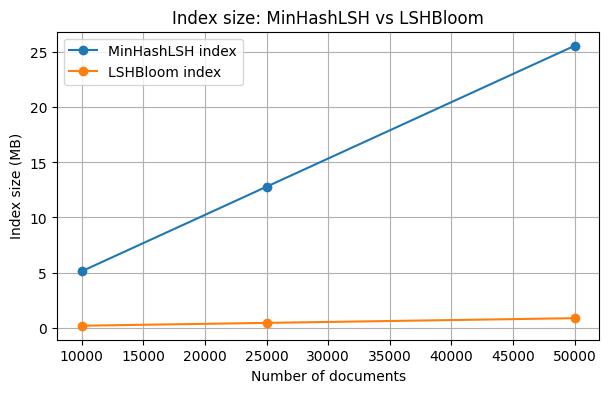

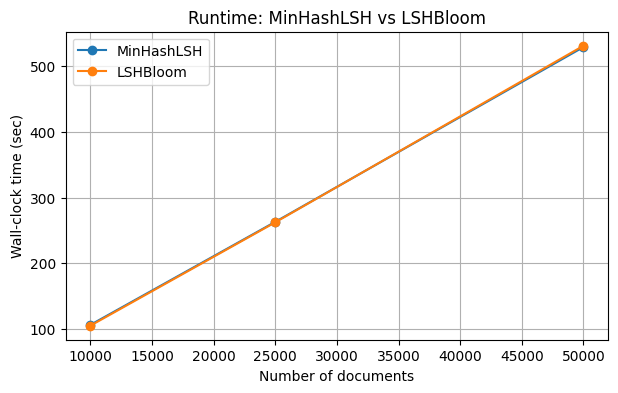

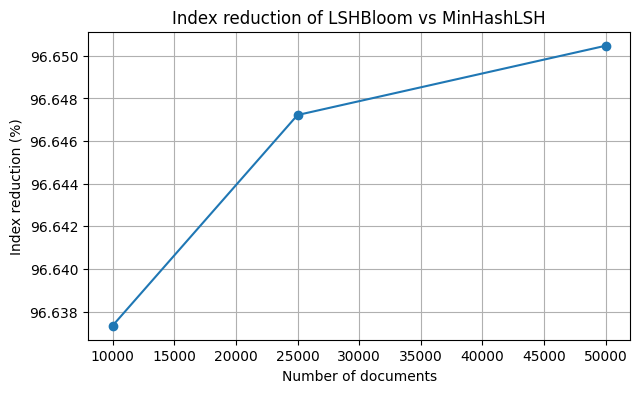

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(compare_df["n_docs"], compare_df["minhash_index_size_bytes"] / (1024**2), marker="o", label="MinHashLSH index")
plt.plot(compare_df["n_docs"], compare_df["lshbloom_index_size_bytes"] / (1024**2), marker="o", label="LSHBloom index")
plt.xlabel("Number of documents")
plt.ylabel("Index size (MB)")
plt.title("Index size: MinHashLSH vs LSHBloom")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(compare_df["n_docs"], compare_df["minhash_wall_clock_sec"], marker="o", label="MinHashLSH")
plt.plot(compare_df["n_docs"], compare_df["lshbloom_wall_clock_sec"], marker="o", label="LSHBloom")
plt.xlabel("Number of documents")
plt.ylabel("Wall-clock time (sec)")
plt.title("Runtime: MinHashLSH vs LSHBloom")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(compare_df["n_docs"], compare_df["index_reduction_pct"], marker="o")
plt.xlabel("Number of documents")
plt.ylabel("Index reduction (%)")
plt.title("Index reduction of LSHBloom vs MinHashLSH")
plt.grid(True)
plt.show()

## 10) Tóm tắt kết quả cuối

In [16]:
summary_cols = [
    "subset_name", "n_docs",
    "minhash_index_size_bytes", "lshbloom_index_size_bytes",
    "index_reduction_x", "index_reduction_pct",
    "minhash_wall_clock_sec", "lshbloom_wall_clock_sec", "runtime_speedup_x",
    "minhash_docs_with_hits", "lshbloom_docs_flagged_duplicate",
]

final_summary = compare_df[summary_cols].copy()
display(final_summary)

final_summary.to_csv(BENCH_ROOT / "final_summary.csv", index=False)
print("Saved final summary:", BENCH_ROOT / "final_summary.csv")

,subset_name,n_docs,minhash_index_size_bytes,lshbloom_index_size_bytes,index_reduction_x,index_reduction_pct,minhash_wall_clock_sec,lshbloom_wall_clock_sec,runtime_speedup_x,minhash_docs_with_hits,lshbloom_docs_flagged_duplicate
0,text_010k,10000,5358907,180202,29.738333,96.637337,106.482769,105.267640,1.011543,0,0
1,text_025k,25000,13415194,449782,29.825991,96.647220,263.057642,262.303765,1.002874,0,0
2,text_050k,50000,26842339,899092,29.854941,96.650471,528.626813,530.662143,0.996165,0,0


Saved final summary: /kaggle/working/lshbloom_vs_phase2/benchmark_runs/final_summary.csv
